# Example Scenarios for SoftwareX Paper

This notebooks simulates the three case studies included in the paper's illustrative example section.
Each case study is defined in a separate CSV file, which is read and processed to run the simulations.

- **Case A - Long-haul**: 30 heavy-duty trucks with ample space for PV expansion
- **Case B - Distribution**: 40 transporters and five small trucks with ample space for PV expansion
- **Case C - Remote Depot**: 10 heavy-duty trucks in short haul logistics operated at a remote depot with limited grid connection, and limited PV expansion

This notebooks reads the case study definitions from the CSV files, runs the simulations for each scenario, and saves the results in two separate CSV files for each case study:
- `case_a_data_time.csv`, `case_b_data_time.csv`, `case_c_data_time.csv`: Contains the time series data of costs (capex and opex) for each scenario, which can be used for plotting the cost evolution over time.
- `case_a_data_total.csv`, `case_b_data_total.csv`, `case_c_data_total.csv`: Contains the total KPIs for each scenario, including total opex, total capex, self-consumption, self-sufficiency, home charging fraction, and total CO2 emissions, which can be used for comparative analysis across scenarios.

After running this notebook, compile the file `results.tex` to create the visualizations and analyses presented in the paper's illustrative example section.

In [27]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd

from lift.backend.scenario import ScenarioResult, SingleScenario
from lift.utils import read_csv

In [2]:
def run_casestudy(casestudy_name: str, casestudy_df: pd.DataFrame):
    results = {scn: SingleScenario.from_series(scn_series).simulate() for scn, scn_series in casestudy_df.iterrows()}

    def costs4plotting(result: ScenarioResult) -> np.ndarray:
        costs = np.zeros(2 * (result.period_eco + 1))
        costs[2::2] = result.opex_dis[:-1]
        costs[1::2] = result.capex_dis
        return np.cumsum(costs)

    df_time = pd.DataFrame(data={k: costs4plotting(v) for k, v in results.items()}) * 1e-6
    df_time["year"] = np.repeat(np.arange(len(df_time) // 2), 2)
    df_time = df_time[["year"] + [col for col in df_time.columns if col != "year"]]
    df_time.to_csv(f"{casestudy_name}_data_time.csv", index=False)

    df_kpis = pd.DataFrame(
        {
            k: {
                "opex": v.opex_dis.sum() * 1e-6,
                "capex": v.capex_dis.sum() * 1e-6,
                "gamma_sc": v.self_consumption,
                "gamma_ss": v.self_sufficiency,
                "gamma_ch": v.home_charging_fraction,
                "co2": v.totem.sum() * 1e-6,
            }
            for k, v in results.items()
        },
        dtype=float,
    ).T
    df_kpis.index.name = "scenario"
    df_kpis[["gamma_sc", "gamma_ss", "gamma_ch"]] = df_kpis[["gamma_sc", "gamma_ss", "gamma_ch"]].fillna(1.1)
    df_kpis.to_csv(f"{casestudy_name}_data_total.csv")

In [3]:
df = read_csv(Path("case_a.csv"), transpose=True)
run_casestudy("A", df)
df = read_csv(Path("case_b.csv"), transpose=True)
run_casestudy("B", df)
df = read_csv(Path("case_c.csv"), transpose=True)
run_casestudy("C", df)

Scenario simulation time: 0.0134 s
Scenario simulation time: 0.2435 s
Scenario simulation time: 0.2511 s
Scenario simulation time: 0.0094 s
Scenario simulation time: 0.3698 s
Scenario simulation time: 0.3680 s
Scenario simulation time: 0.0102 s
Scenario simulation time: 0.0907 s
Scenario simulation time: 0.0945 s


## Sensitivity Analysis
To validate the results, the following section performs a sensitivity analysis for several parameters of Use Case A

In [15]:
df = read_csv(Path("case_a.csv"), transpose=True)

# extract 3rd scenario (fleet electrification + depot expansion)
base_row = df.loc["cost3", :]

capacities = np.arange(0, 1001e3, 25e3)

rows = []
for capacity in capacities:
    row = base_row.copy()
    row[("ess", "capacity")] = capacity
    rows.append(row)

df_pv = pd.DataFrame(rows)
df_pv.index = [f"pv_{int(capacity / 1000)}kW" for capacity in capacities]

results = {scn: SingleScenario.from_series(scn_series).simulate() for scn, scn_series in df_pv.iterrows()}

Scenario simulation time: 0.2483 s
Scenario simulation time: 0.2473 s
Scenario simulation time: 0.2573 s
Scenario simulation time: 0.2498 s
Scenario simulation time: 0.2460 s
Scenario simulation time: 0.2478 s
Scenario simulation time: 0.2452 s
Scenario simulation time: 0.2483 s
Scenario simulation time: 0.2518 s
Scenario simulation time: 0.2476 s
Scenario simulation time: 0.2518 s
Scenario simulation time: 0.2532 s
Scenario simulation time: 0.2575 s
Scenario simulation time: 0.2513 s
Scenario simulation time: 0.2532 s
Scenario simulation time: 0.2509 s
Scenario simulation time: 0.2541 s
Scenario simulation time: 0.2535 s
Scenario simulation time: 0.2482 s
Scenario simulation time: 0.2522 s
Scenario simulation time: 0.2593 s
Scenario simulation time: 0.2474 s
Scenario simulation time: 0.2457 s
Scenario simulation time: 0.2456 s
Scenario simulation time: 0.2466 s
Scenario simulation time: 0.2527 s
Scenario simulation time: 0.2461 s
Scenario simulation time: 0.2553 s
Scenario simulation 

In [34]:

df_results = pd.DataFrame.from_dict(
    {
        k: {
            "totex": v.totex_dis.sum(),
            "capex": v.capex_dis.sum(),
            "opex": v.opex_dis.sum(),
            "gamma_sc": v.self_consumption,
            "gamma_ss": v.self_sufficiency,
            "gamma_hc": v.home_charging_fraction,
        }
        for k, v in results.items()
    },
    orient="index"
)



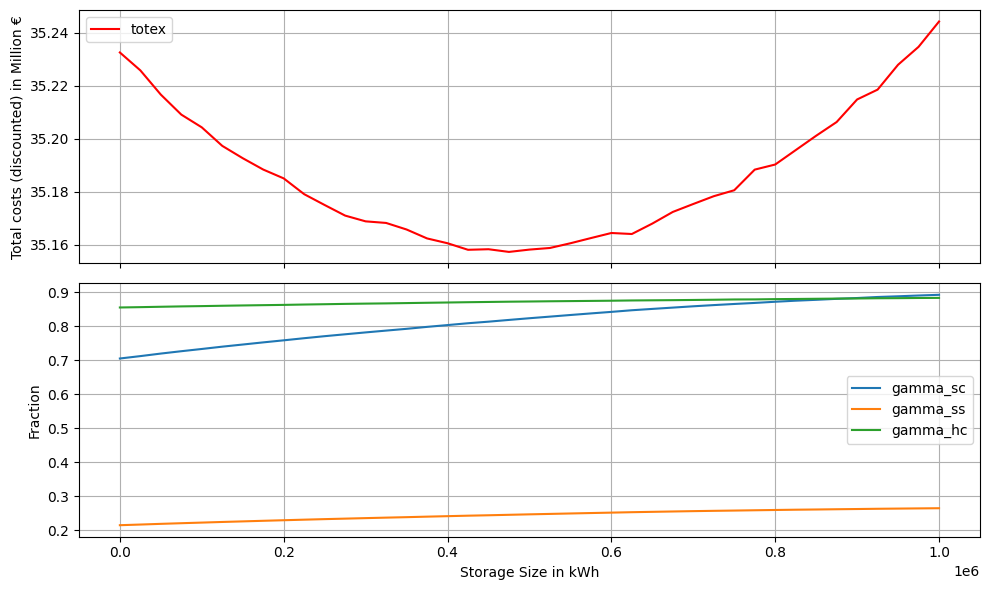

In [ ]:
import matplotlib.pyplot as plt

COLORS = {
    ""
}

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# Cost plot
ax1.plot(capacities, df_results["totex"] / 1e6, label="totex", color=COLORS["tumblue"])

ax1.set_ylabel("Total costs (discounted) in Million €")
ax1.legend()
ax1.grid(True)

# KPI plot
ax2.set_xlabel("Storage Size in kWh")
ax2.set_ylabel("Fraction")
ax2.grid(True)
ax2.plot(capacities, df_results["gamma_sc"], label="gamma_sc", color=COLORS["range"])
ax2.plot(capacities, df_results["gamma_ss"], label="gamma_ss", color=COLORS["green"])
ax2.plot(capacities, df_results["gamma_hc"], label="gamma_hc", color=COLORS[""])
ax2.legend()

# plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()